# Wind Resource Emulator -- from 24 fixed years to a continuous, perturbable wind climate

The pipeline so far samples wind climate from exactly 24 discrete `UniformWeibullSite` objects, one per ERA5 year (2000-2023) -- a fixed, finite set. Here, I replace that with a generative emulator: PCA over the 24-year parameter space, so the Monte Carlo can draw as many plausible wind climates as needed, including deliberately extreme ones, instead of only re-picking among 24 historical years.


In [1]:

# ENVIRONMENT CHECK -- run this first. Installs/upgrades this kernel's
# environment to the exact package versions this notebook was tested with.
# ===============================
import importlib.metadata 
import subprocess
import sys

from IPython.core.pylabtools import figsize

REQUIRED = {
    "numpy": "2.3.2", "scipy": "1.17.1", "matplotlib": "3.10.6", "xarray": "2025.1.0",
    "shapely": "2.1.2", "pyproj": "3.7.0", "openmdao": "3.40.0", "windIO": "2.1.1",
    "py_wake": "2.6.20", "optiwindnet": "0.3.0", "ortools": "9.15.6755",
    "h5py": "3.16.0", "netCDF4": "1.7.4", "openturns": "1.27.post1", "scikit-learn": "1.9.0",
}

def installed(pkg):
    try:
        return importlib.metadata.version(pkg)
    except importlib.metadata.PackageNotFoundError:
        return None

mismatched = {p: v for p, v in REQUIRED.items() if installed(p) != v}

if mismatched:
    print(f"Installing {len(mismatched)} package(s) to the versions this notebook was tested with...")
    for pkg, version in mismatched.items():
        print(f"  {pkg}=={version} ...")
        result = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', f'{pkg}=={version}'],
                                 capture_output=True, text=True)
        if result.returncode != 0:
            print(result.stdout[-2000:])
            print(result.stderr[-2000:])
            raise RuntimeError(
                f"Could not install '{pkg}=={version}' automatically. Install it manually in this "
                f"kernel's environment (`{sys.executable} -m pip install {pkg}=={version}`) and re-run "
                f"this cell.")
    importlib.metadata.invalidate_caches()

print("Environment OK -- all versions match what this notebook was tested with.")

Environment OK -- all versions match what this notebook was tested with.


In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

sys.path.insert(0, str(Path("..") / ".." / "Project_Monte_Carlo"))
from download_era5_vineyard import load_wind_series, LAT_CENTER, LON_CENTER
from build_pywake_sites import fit_sector_weibull, YEARS, N_SECTORS
from py_wake.site import UniformWeibullSite

ERA5_DIR = Path("..") / ".." / "Project_Monte_Carlo" / "era5_vineyard"
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
TI = 0.06
SECTOR_DEG = np.linspace(0, 360, N_SECTORS, endpoint=False)

/opt/anaconda3/envs/wesl_jul_31/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 24 fixed sites

Each ERA5 year is reduced to 36 numbers: 12 sectors x (frequency, Weibull A, Weibull k). 

In [3]:
from tqdm import tqdm

rows = []
wind_data = []
    
for year in tqdm(YEARS):
    path = ERA5_DIR / f"era5_{year}.grib"
    _t, speed, direction = load_wind_series(str(path), LAT_CENTER, LON_CENTER)
    wind_data.append({'time': _t, 'w_s': speed, 'w_d': direction})
    
    freq, A, k = fit_sector_weibull(speed, direction)
    rows.append(np.concatenate([freq, A, k]))
    print(f"{year}: mean speed {speed.mean():.2f} m/s")

REAL_MATRIX = np.array(rows)  # 24 x 36 (12 freq, 12 A, 12 k)
print(f"\nREAL_MATRIX shape: {REAL_MATRIX.shape}")


  0%|          | 0/24 [00:00<?, ?it/s]

Ignoring index file '../../Project_Monte_Carlo/era5_vineyard/era5_2000.grib.5b7b6.idx' incompatible with GRIB file



  4%|▍         | 1/24 [00:07<02:50,  7.40s/it]

Ignoring index file '../../Project_Monte_Carlo/era5_vineyard/era5_2001.grib.5b7b6.idx' incompatible with GRIB file


2000: mean speed 9.17 m/s


...

Ignoring index file '../../Project_Monte_Carlo/era5_vineyard/era5_2023.grib.5b7b6.idx' incompatible with GRIB file


2022: mean speed 9.22 m/s



100%|██████████| 24/24 [02:33<00:00,  6.34s/it]


100%|██████████| 24/24 [02:33<00:00,  6.40s/it]

2023: mean speed 8.53 m/s

REAL_MATRIX shape: (24, 36)


## 2. A few real roses

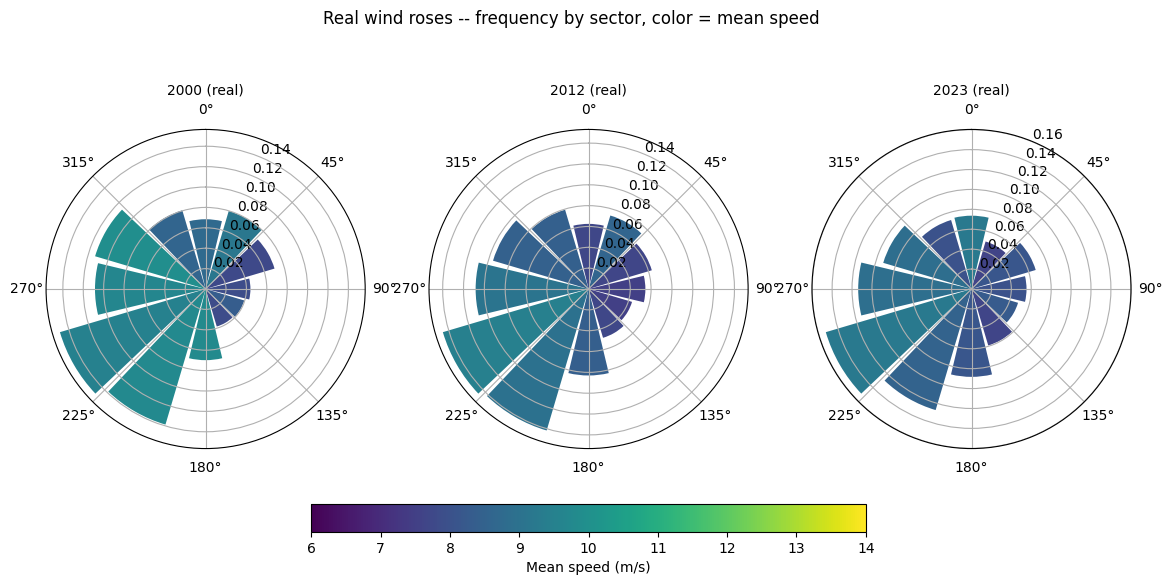

In [4]:
SPEED_VMIN, SPEED_VMAX = 6.0, 14.0  # shared color scale across every rose plot in this notebook

def rose_from_row(row):
    freq, A, k = row[:12], row[12:24], row[24:36]
    mean_speed = A * gamma(1 + 1 / k)
    return freq, mean_speed

def plot_rose(ax, row, title):
    freq, mean_speed = rose_from_row(row)
    theta = np.radians(SECTOR_DEG)
    norm = plt.Normalize(SPEED_VMIN, SPEED_VMAX)
    ax.bar(theta, freq, width=2 * np.pi / N_SECTORS * 0.9, color=plt.cm.viridis(norm(mean_speed)))
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(title, fontsize=10)

def add_speed_colorbar(fig, axes):
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(SPEED_VMIN, SPEED_VMAX))
    sm.set_array([])
    fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.06, pad=0.12, label="Mean speed (m/s)")

fig, axes = plt.subplots(1, 3, figsize=(14, 6), subplot_kw={"projection": "polar"})
for ax, year in zip(axes, [YEARS[0], YEARS[len(YEARS) // 2], YEARS[-1]]):
    plot_rose(ax, REAL_MATRIX[YEARS.index(year)], f"{year} (real)")
add_speed_colorbar(fig, axes)
fig.suptitle("Real wind roses -- frequency by sector, color = mean speed")
fig.savefig(FIGURES_DIR / "real_roses_sample.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. PCA over the 24-year parameter space

Standardize the 36 columns, then decompose with SVD. The scree plot shows how many modes are needed before adding more stops explaining meaningful variance.

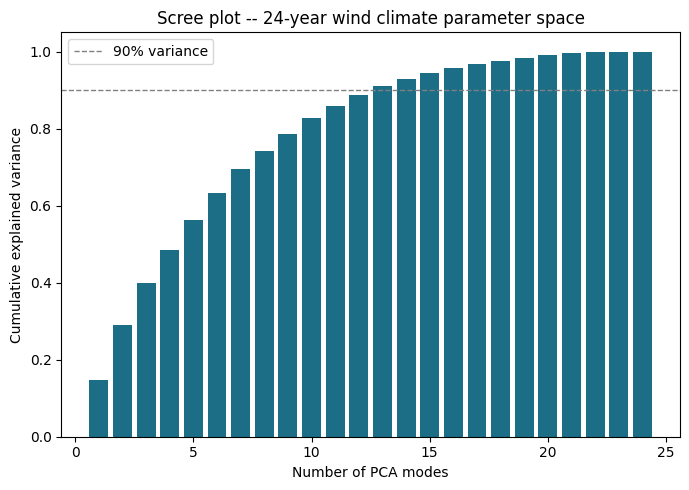

Modes needed for 90% variance: 13 (of 24 possible)


In [5]:
COL_MEAN = REAL_MATRIX.mean(axis=0)
COL_STD = REAL_MATRIX.std(axis=0)
STD_MATRIX = (REAL_MATRIX - COL_MEAN) / COL_STD

U, S, Vt = np.linalg.svd(STD_MATRIX, full_matrices=False)
explained_var = S ** 2 / np.sum(S ** 2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(range(1, len(explained_var) + 1), np.cumsum(explained_var), color="#1B6E86")
ax.axhline(0.9, color="gray", linestyle="--", linewidth=1, label="90% variance")
ax.set_xlabel("Number of PCA modes")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Scree plot -- 24-year wind climate parameter space")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pca_scree_plot.png", dpi=180, bbox_inches="tight")
plt.show()

N_MODES = int(np.searchsorted(np.cumsum(explained_var), 0.9) + 1)
print(f"Modes needed for 90% variance: {N_MODES} (of {len(explained_var)} possible)")

## 4. Sampling synthetic roses

In PCA space the mode scores are independent, each with variance equal to its own eigenvalue -- so a synthetic draw is just independent normal samples per mode, scaled by `S`, reconstructed back into freq/A/k, then clipped to stay physical (frequencies non-negative and renormalized to sum to 1; A and k kept positive). `extreme_modes` optionally restricts the `scale` multiplier to only the strongest modes (PC1, PC2, ...), leaving the weaker/noisier modes at their natural size -- see 5 for why.

In [6]:
def sample_synthetic_row(rng, n_modes=N_MODES, scale=1.0, extreme_modes=None):
    scale_vec = np.full(n_modes, scale if extreme_modes is None else 1.0)
    if extreme_modes is not None:
        scale_vec[:extreme_modes] = scale

    scores = rng.normal(0, 1, size=n_modes) * scale_vec * S[:n_modes] / np.sqrt(len(REAL_MATRIX) - 1)
    std_row = scores @ Vt[:n_modes]
    row = std_row * COL_STD + COL_MEAN

    freq, A, k = row[:12], row[12:24], row[24:36]
    freq = np.clip(freq, 1e-4, None)
    freq = freq / freq.sum()
    A = np.clip(A, 0.5, None)
    k = np.clip(k, 0.3, None)
    return np.concatenate([freq, A, k])

def sample_synthetic_site(rng, n_modes=N_MODES, scale=1.0, extreme_modes=None, ti=TI):
    row = sample_synthetic_row(rng, n_modes=n_modes, scale=scale, extreme_modes=extreme_modes)
    freq, A, k = row[:12], row[12:24], row[24:36]
    return UniformWeibullSite(p_wd=list(freq), a=list(A), k=list(k), ti=ti)

## 5. Normal vs. extreme synthetic roses

`scale=1` draws stay inside the range the 24 real years already show.

For "extreme", pushing *all* 13 modes to 3x their natural spread at once compounds into combinations no real year ever showed even loosely -- modes 4-13 are individually weak/noisy, and randomly maxing out all of them together can rotate the dominant direction to somewhere the real 24-year record never points to, which stops looking like "an extreme version of Vineyard's climate" and starts looking like an unrelated location. Instead, `extreme_modes=3` pushes only PC1-PC3 -- the strongest, most physically real patterns -- to `scale=3`, and leaves the weaker modes at their natural size. That keeps the extreme draw anchored to Vineyard's own dominant modes of variability, just pushed hard along them, closer to how a genuinely unusual real year would behave (a large coherent shift, not thirteen simultaneous independent ones).

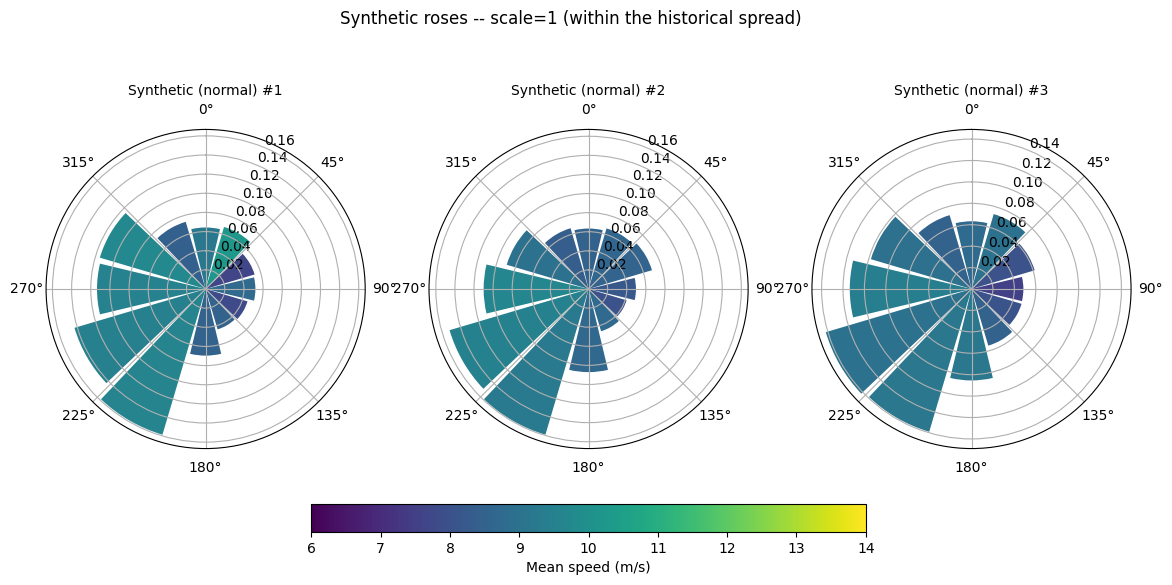

In [7]:
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 3, figsize=(14, 6), subplot_kw={"projection": "polar"})
for i, ax in enumerate(axes):
    row = sample_synthetic_row(rng, scale=1.0)
    plot_rose(ax, row, f"Synthetic (normal) #{i+1}")
add_speed_colorbar(fig, axes)
fig.suptitle("Synthetic roses -- scale=1 (within the historical spread)")
fig.savefig(FIGURES_DIR / "synthetic_roses_normal.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Validation -- synthetic spread vs. real spread

200 `scale=1` synthetic draws, compared against the 24 real years on two summary statistics: overall mean wind speed and the frequency of the dominant sector. The synthetic cloud should surround the real points, not sit off to one side of them.

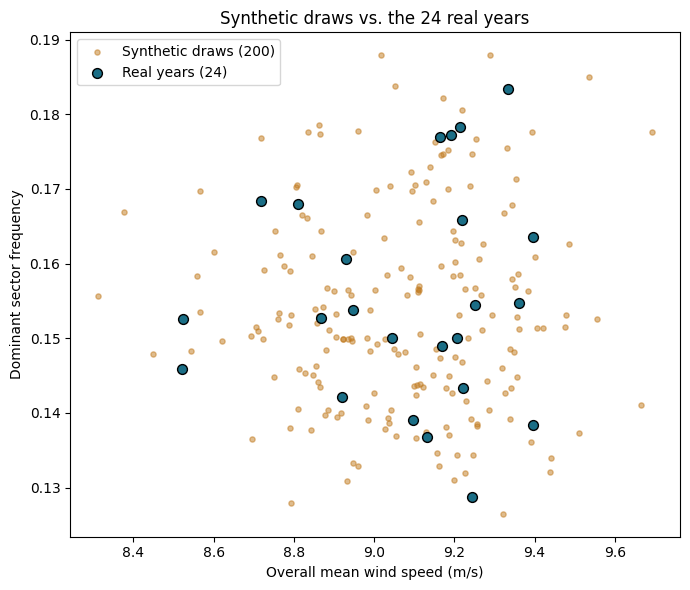

In [10]:
def summary_stats(row):
    freq, mean_speed = rose_from_row(row)
    overall_mean_speed = np.sum(freq * mean_speed)
    dominant_freq = freq.max()
    return overall_mean_speed, dominant_freq

real_stats = np.array([summary_stats(row) for row in REAL_MATRIX])
synthetic_stats = np.array([summary_stats(sample_synthetic_row(rng, scale=1.0)) for _ in range(200)])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(synthetic_stats[:, 0], synthetic_stats[:, 1], s=14, color="#C17A1F", alpha=0.5, label="Synthetic draws (200)")
ax.scatter(real_stats[:, 0], real_stats[:, 1], s=50, color="#1B6E86", edgecolor="black", label="Real years (24)")
ax.set_xlabel("Overall mean wind speed (m/s)")
ax.set_ylabel("Dominant sector frequency")
ax.set_title("Synthetic draws vs. the 24 real years")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "validation_synthetic_vs_real.png", dpi=180, bbox_inches="tight")
plt.show()

### 6.1 Performance Index -- reconstruction fidelity

Same validation style as Skittides, C.; Fruh, W.-G. **"A new Measure-Correlate-Predict Wind Resource Prediction method."** ICREPQ'15, La Coruna, Spain, 2015: compare the actual and predicted wind speed *distributions* (1 m/s bins), take the total absolute error between them, and express it as a **Performance Index** relative to a baseline. Their baseline was linear-regression MCP; ours is the flat 24-year mean rose (i.e., the single fixed climate the old pipeline effectively assumed everywhere).

For each real year, this projects that year into the truncated `N_MODES`-dimension PCA space and reconstructs it back -- exactly the compression the emulator performs when sampling -- and checks whether the reconstructed distribution still resembles that year's real distribution better than just assuming the flat mean. `PI < 1` means the truncated PCA model keeps real year-to-year information; `PI` close to 1 means truncation threw away too much and the emulator is no better than a single fixed climate.

In [11]:
WS_BINS = np.arange(0.5, 30.5, 1.0)

def marginal_speed_pdf(row, ws_bins=WS_BINS):
    freq, A, k = row[:12], row[12:24], row[24:36]
    pdf = np.zeros_like(ws_bins)
    for f, a, kk in zip(freq, A, k):
        pdf += f * (kk / a) * (ws_bins / a) ** (kk - 1) * np.exp(-(ws_bins / a) ** kk)
    return pdf / pdf.sum()

def reconstruct_row(row, n_modes=N_MODES):
    std_row = (row - COL_MEAN) / COL_STD
    scores = std_row @ Vt[:n_modes].T
    std_recon = scores @ Vt[:n_modes]
    return std_recon * COL_STD + COL_MEAN

flat_pdf = marginal_speed_pdf(COL_MEAN)

errors_pca, errors_flat = [], []
for row in REAL_MATRIX:
    actual_pdf = marginal_speed_pdf(row)
    recon_pdf = marginal_speed_pdf(reconstruct_row(row))
    errors_pca.append(np.sum(np.abs(actual_pdf - recon_pdf)))
    errors_flat.append(np.sum(np.abs(actual_pdf - flat_pdf)))

errors_pca = np.array(errors_pca)
errors_flat = np.array(errors_flat)
performance_index = errors_pca / errors_flat
print(f"Performance Index: mean={performance_index.mean():.2f}, median={np.median(performance_index):.2f}")

Performance Index: mean=0.20, median=0.15


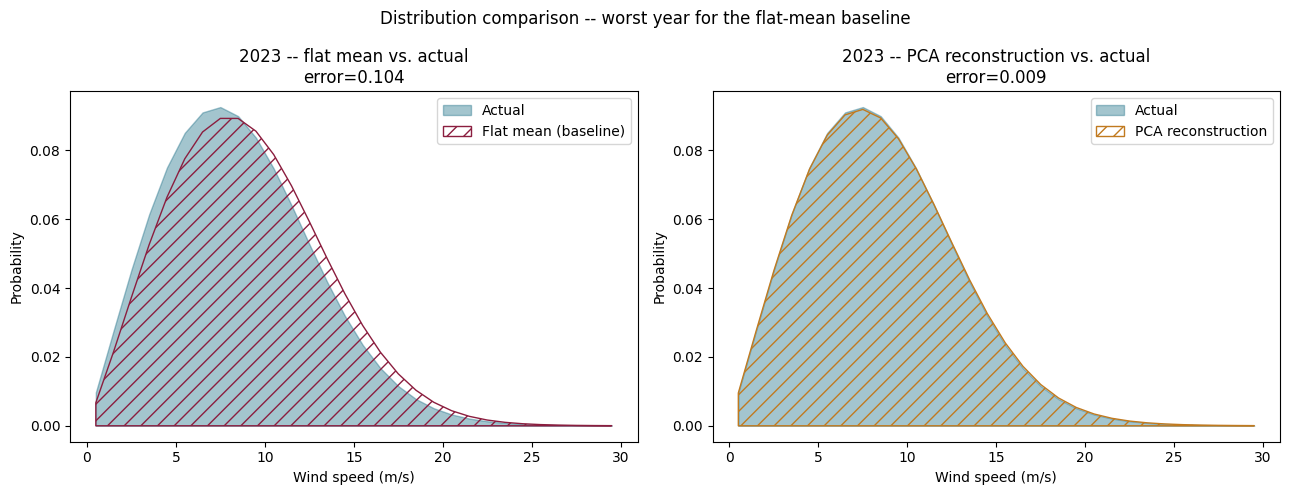

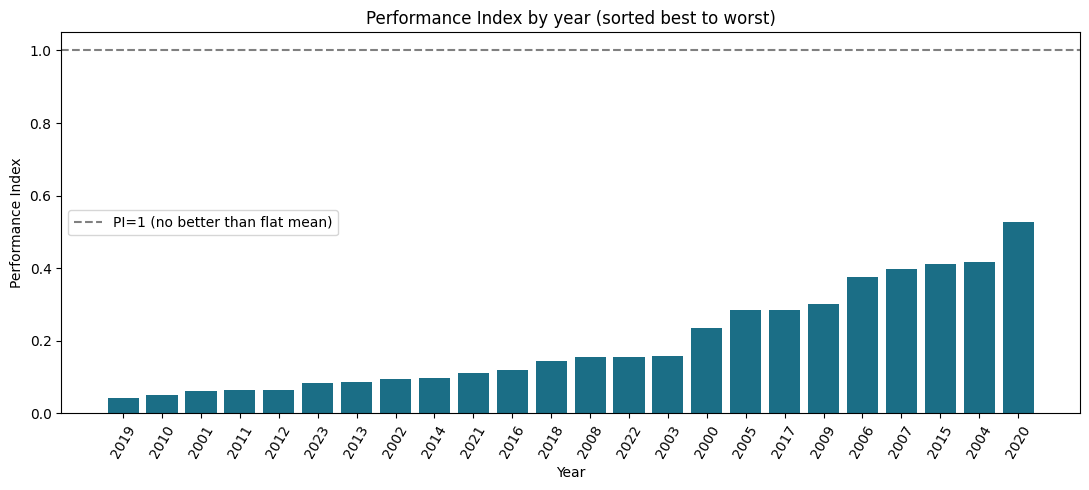

In [12]:
example = np.argmax(errors_flat)  # the year the flat baseline struggles with most
actual_pdf = marginal_speed_pdf(REAL_MATRIX[example])
recon_pdf = marginal_speed_pdf(reconstruct_row(REAL_MATRIX[example]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].fill_between(WS_BINS, actual_pdf, color="#1B6E86", alpha=0.4, label="Actual")
axes[0].fill_between(WS_BINS, flat_pdf, color="none", edgecolor="#8B1E3F", hatch="//", label="Flat mean (baseline)")
axes[0].set_title(f"{YEARS[example]} -- flat mean vs. actual\nerror={errors_flat[example]:.3f}")

axes[1].fill_between(WS_BINS, actual_pdf, color="#1B6E86", alpha=0.4, label="Actual")
axes[1].fill_between(WS_BINS, recon_pdf, color="none", edgecolor="#C17A1F", hatch="//", label="PCA reconstruction")
axes[1].set_title(f"{YEARS[example]} -- PCA reconstruction vs. actual\nerror={errors_pca[example]:.3f}")

for ax in axes:
    ax.set_xlabel("Wind speed (m/s)")
    ax.set_ylabel("Probability")
    ax.legend()
fig.suptitle("Distribution comparison -- worst year for the flat-mean baseline")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "performance_index_example_year.png", dpi=180, bbox_inches="tight")
plt.show()

order = np.argsort(performance_index)
years_sorted = [YEARS[i] for i in order]
pi_sorted = performance_index[order]

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#1B6E86" if pi < 1 else "#8B1E3F" for pi in pi_sorted]
ax.bar(years_sorted, pi_sorted, color=colors)
ax.axhline(1.0, color="gray", linestyle="--", label="PI=1 (no better than flat mean)")
ax.set_xlabel("Year")
ax.set_ylabel("Performance Index")
ax.set_title("Performance Index by year (sorted best to worst)")
ax.tick_params(axis="x", rotation=60)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "performance_index_by_year.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Old vs. new: 24 fixed points vs. a continuous cloud

Same comparison, now directly in PCA space (first two modes). The 24 real years are what the old pipeline could ever draw; the cloud is everything the emulator can now generate.

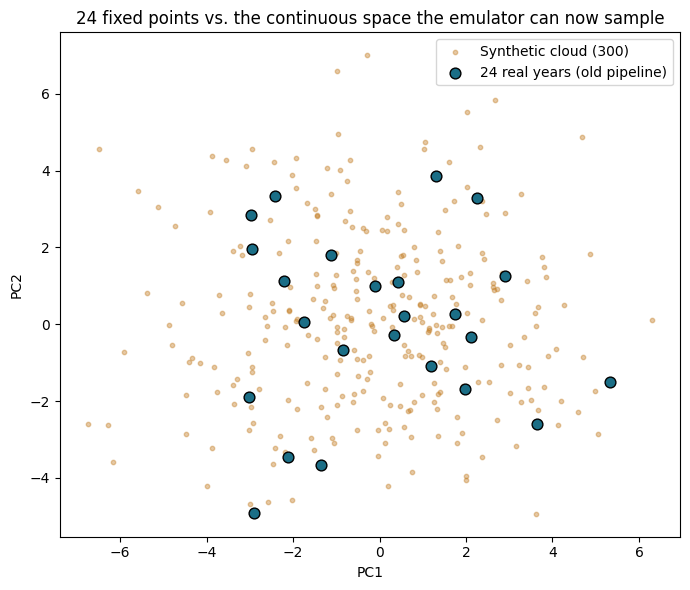

In [13]:
real_scores = STD_MATRIX @ Vt[:2].T
synthetic_scores = np.array([
    (rng.normal(0, 1, size=N_MODES) * S[:N_MODES] / np.sqrt(len(REAL_MATRIX) - 1))[:2]
    for _ in range(300)
])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(synthetic_scores[:, 0], synthetic_scores[:, 1], s=10, color="#C17A1F", alpha=0.4, label="Synthetic cloud (300)")
ax.scatter(real_scores[:, 0], real_scores[:, 1], s=60, color="#1B6E86", edgecolor="black", label="24 real years (old pipeline)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("24 fixed points vs. the continuous space the emulator can now sample")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "old_vs_new_pca_space.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. A von Mises alternative -colaborative work

### 8.1 Raw wind vectors, all 24 years pooled

Every hour of every year, not the 36-number-per-year summary -- `u`/`v` components let the joint speed-direction density show up directly in a KDE, no binning yet.

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [15]:
"""changes"""
# concat straight from the per-year df (not from an empty seed),, avoids the columns silently becoming object dtype, which breaks np.cos()/np.sin() a couple cells down
df = pd.concat([pd.DataFrame(data) for data in wind_data], ignore_index=True)

In [16]:
df['year'] = df.apply(lambda r: r.time.year, axis=1)

In [17]:
df['u'] = df.w_s*np.cos(df.w_d*np.pi/180)
df['v'] = df.w_s*np.sin(df.w_d*np.pi/180)

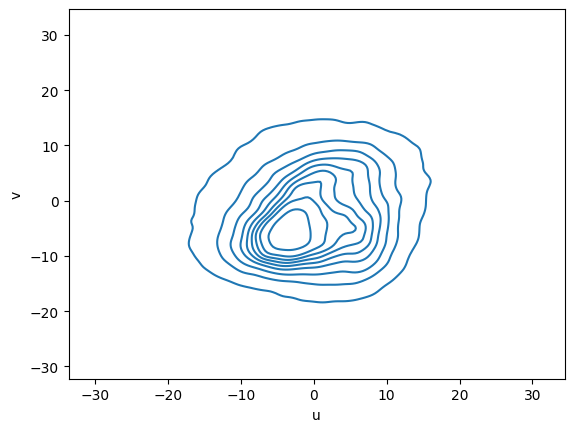

In [18]:
sns.kdeplot(data=df, x='u', y='v')
plt.show()

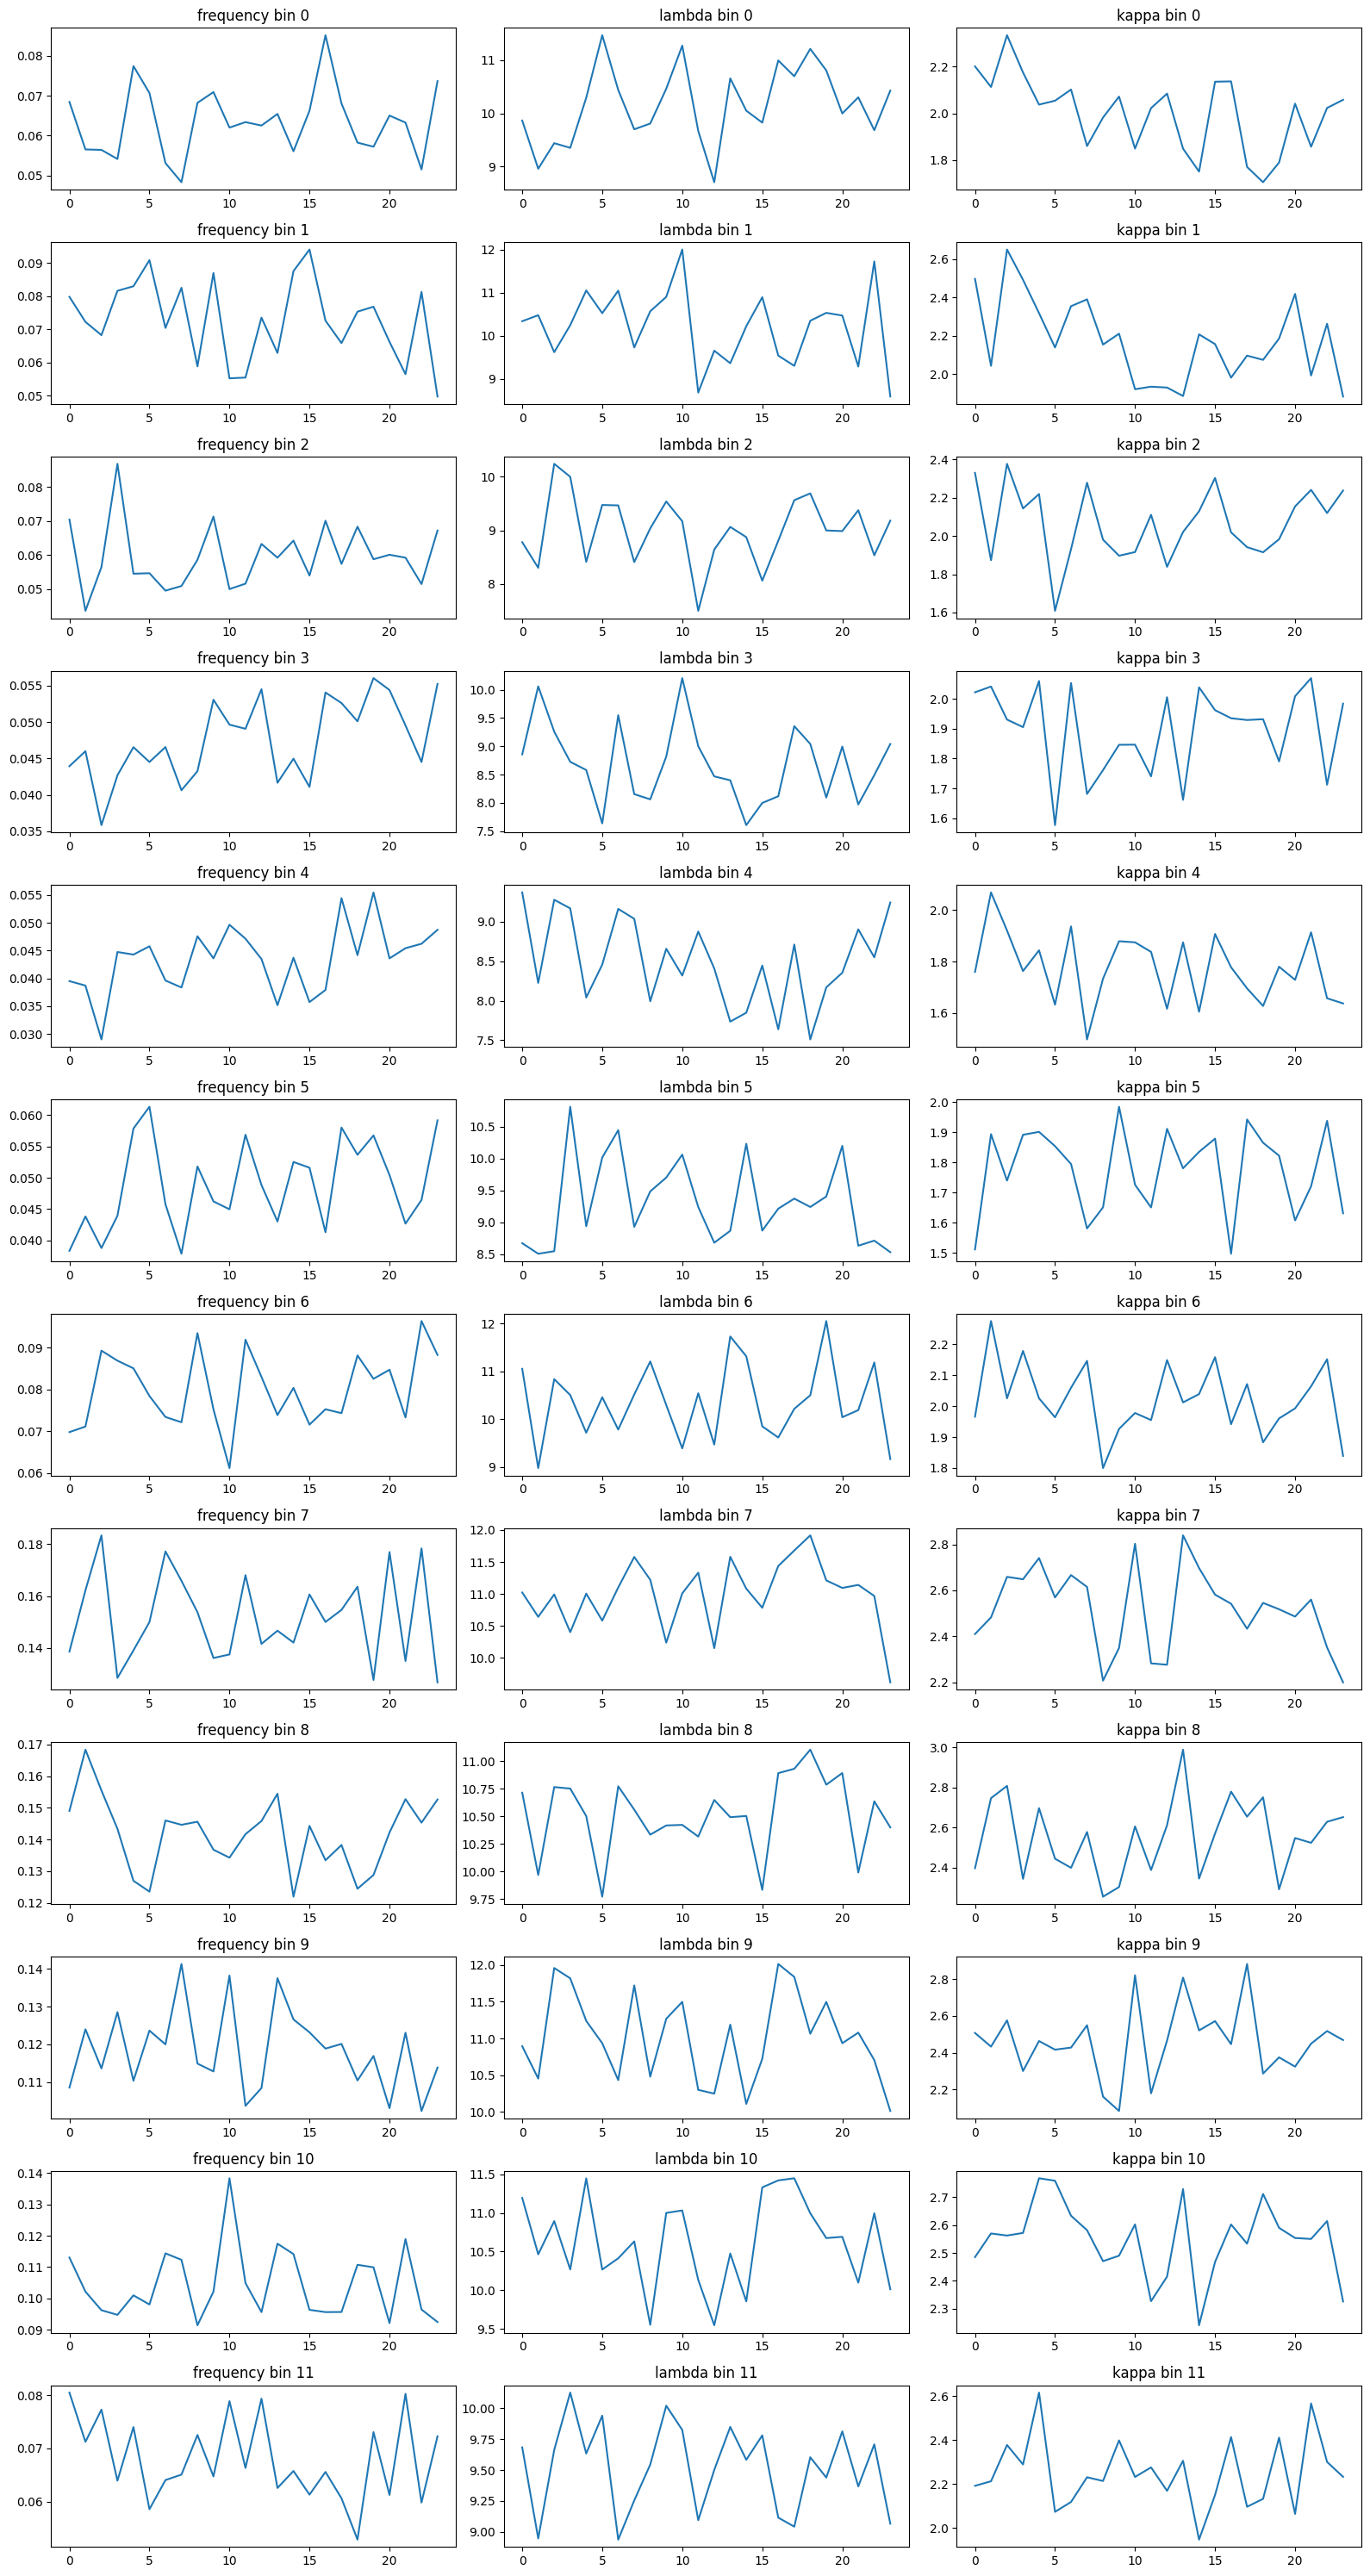

In [19]:
fig, axs = plt.subplots(12, 3, figsize=(16, 30))

for i, (ax1, ax2, ax3) in enumerate(axs):
    ax1.plot([row[i] for row in rows])
    ax1.set_title(f'frequency bin {i}')

    ax2.plot([row[i + N_SECTORS] for row in rows])
    ax2.set_title(f'lambda bin {i}')
    
    ax3.plot([row[i + 2*N_SECTORS] for row in rows])
    ax3.set_title(f'kappa bin {i}')

plt.tight_layout()
plt.show()

In [20]:
zipped_data = list(zip(*rows))
weibull_distros = pd.DataFrame(columns=['sector', 'frequency', 'lambda', 'kappa'])
for sector in range(N_SECTORS):
    weibull_distros = pd.concat([weibull_distros, pd.DataFrame({'sector': sector, 'frequency': zipped_data[sector], 'lambda': zipped_data[sector + N_SECTORS], 'kappa': zipped_data[sector + 2 * N_SECTORS]})])

weibull_distros

,sector,frequency,lambda,kappa
0,0,0.06842,9.866072,2.201265
1,0,0.056507,8.960134,2.112979
2,0,0.056393,9.440379,2.335003
3,0,0.05411,9.35244,2.175019
4,0,0.077413,10.295185,2.03738
...,...,...,...,...
19,11,0.073059,9.44015,2.411554
20,11,0.061248,9.81382,2.064603
21,11,0.080251,9.368344,2.567265
22,11,0.059817,9.709046,2.300974


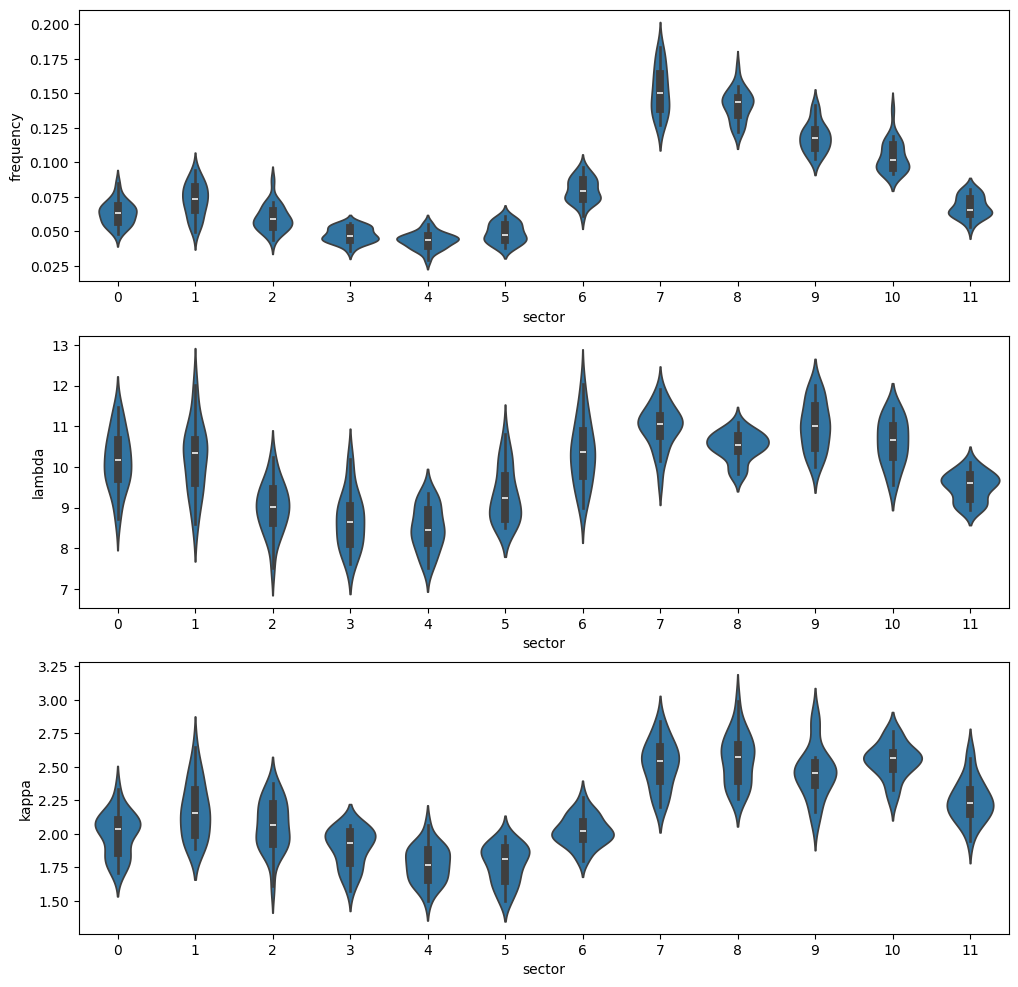

In [21]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))
sns.violinplot(data=weibull_distros, y='frequency', x='sector', ax=ax1)
sns.violinplot(data=weibull_distros, y='lambda', x='sector', ax=ax2)
sns.violinplot(data=weibull_distros, y='kappa', x='sector', ax=ax3)
plt.show()

### 8.3 Pooled wind direction, fine-grained

All 24 years of raw direction readings in one array, histogrammed at 5-degree resolution -- much finer than the 12-sector view above.

In [22]:
directions = np.array([])
for _wind_data in wind_data:
    directions = np.concat((directions, _wind_data.get('w_d')))

<Axes: ylabel='Count'>

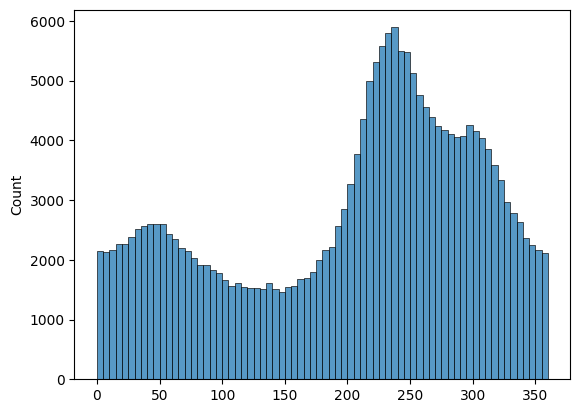

In [23]:
sns.histplot(directions, bins=72)

In [ ]:
import numpy as np
from scipy.special import i0

def vonmises_pdf(x, mu, kappa):
    # i0 is the modified Bessel function of the first kind of order 0
    return np.exp(kappa * np.cos(x - mu)) / (2 * np.pi * i0(kappa))

def fit_von_mises_mixture(X, K=2, max_iter=100, tol=1e-4):
    N = len(X)
    mu = np.linspace(-np.pi, np.pi, K + 1)[:K]
    kappa = np.ones(K) * 2.0
    weights = np.ones(K) / K

    for iteration in range(max_iter):
        #posterior probabilities
        responsibilities = np.zeros((N, K))
        for k in range(K):
            responsibilities[:, k] = weights[k] * vonmises_pdf(X, mu[k], kappa[k])

        # Normalize responsibilities across components per data point
        row_sums = responsibilities.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1e-12  # Avoid division by zero
        responsibilities /= row_sums
        
        # update component weights, means (mu), and concentrations (kappa
        N_k = responsibilities.sum(axis=0)
        weights = N_k / N

        old_mu = mu.copy()

        for k in range(K):
            if N_k[k] < 1e-5:
                continue

            # Update weighted mean direction (mu) using arctan2 for circular data
            sin_sum = np.sum(responsibilities[:, k] * np.sin(X))
            cos_sum = np.sum(responsibilities[:, k] * np.cos(X))
            mu[k] = np.arctan2(sin_sum, cos_sum)

            # Update concentration (kappa) using Banerjee et al. (2005) approximation
            R_bar = np.sqrt(sin_sum**2 + cos_sum**2) / N_k[k]

            if R_bar < 0.53:
                kappa[k] = 2 * R_bar + R_bar**3 + (5 * R_bar**5) / 6
            elif R_bar < 0.85:
                kappa[k] = -0.4 + 1.39 * R_bar + 0.43 / (1 - R_bar)
            else:
                kappa[k] = 1 / (R_bar**3 - 4 * R_bar**2 + 3 * R_bar)

            # Clip kappa to prevent numerical overflow in exponential steps
            kappa[k] = np.clip(kappa[k], 0.1, 50.0)

        # Check for convergence
        if np.allclose(mu, old_mu, atol=tol):
            break

    return weights, mu, kappa


if __name__ == "__main__":
    # np.random.seed(1)
    np.random.seed(42)
    component_1 = np.random.vonmises(mu=1.0, kappa=4.0, size=200)
    component_2 = np.random.vonmises(mu=-2.0, kappa=6.0, size=300)
    component_3 = np.random.vonmises(mu=2.0, kappa=5.0, size=100)
    data = np.concatenate([component_1, component_2, component_3])

   
    rad_directions = np.radians(directions)
    estimated_weights, estimated_mus, estimated_kappas = fit_von_mises_mixture(rad_directions, K=5)

    # Display results
    for i in range(len(estimated_weights)):
        print(f"Component {i+1}:")
        print(f"  Weight:        {estimated_weights[i]:.3f}")
        print(f"  Mean (μ):      {estimated_mus[i]:.3f} rad")
        print(f"  Kappa (κ):     {estimated_kappas[i]:.3f}\n")

Component 1:
  Weight:        0.144
  Mean (μ):      -2.433 rad
  Kappa (κ):     1.120

Component 2:
  Weight:        0.291
  Mean (μ):      -2.172 rad
  Kappa (κ):     4.192

Component 3:
  Weight:        0.237
  Mean (μ):      -0.947 rad
  Kappa (κ):     3.533

Component 4:
  Weight:        0.179
  Mean (μ):      0.700 rad
  Kappa (κ):     2.630

Component 5:
  Weight:        0.149
  Mean (μ):      2.090 rad
  Kappa (κ):     1.241



### fitted mixture vs. the empirical histogram


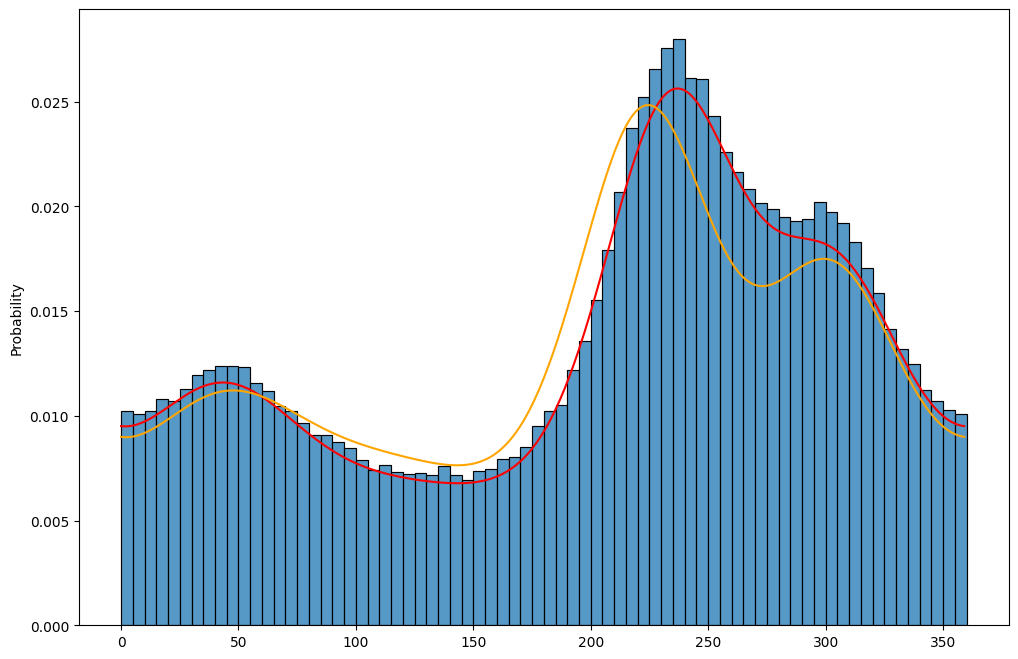

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

sns.histplot(directions, bins=72, ax=ax, stat='probability')
prob = []
prob_ = []
# np.random.seed(42)
estimated_mus_ = estimated_mus + np.random.normal(scale=0.2, size=estimated_mus.size)
estimated_kappas_ = estimated_kappas  + np.random.normal(scale=0.2, size=estimated_kappas.size)

for theta in np.linspace(0, 2*np.pi, 360):
    prob.append(sum([w * vonmises_pdf(theta, mu, kappa) for w, mu, kappa in zip(estimated_weights, estimated_mus, estimated_kappas)]) / 12)
    prob_.append(sum([w * vonmises_pdf(theta, mu, kappa) for w, mu, kappa in zip(estimated_weights, estimated_mus_, estimated_kappas_)]) / 12)

sns.lineplot(prob, ax=ax, c='r')
sns.lineplot(prob_, ax=ax, c='orange')

plt.show()

In [26]:
estimated_mus.size

5

## weibull speed conditioned on direction regime


In [27]:
from scipy.stats import weibull_min

speeds = np.array([])
for _wind_data in wind_data:
    speeds = np.concat((speeds, _wind_data.get('w_s')))

def component_responsibilities(theta, weights, mus, kappas):
    r = np.array([w * vonmises_pdf(theta, mu, k) for w, mu, k in zip(weights, mus, kappas)])
    return r / r.sum(axis=0)

resp = component_responsibilities(rad_directions, estimated_weights, estimated_mus, estimated_kappas)
component_id = resp.argmax(axis=0)

component_C, component_k = [], []
for m in range(len(estimated_weights)):
    mask = component_id == m
    k_fit, _loc, C_fit = weibull_min.fit(speeds[mask], floc=0)
    component_C.append(C_fit)
    component_k.append(k_fit)
    print(f"component {m}: n={mask.sum()}, dir={np.degrees(estimated_mus[m]) % 360:.0f} deg, "
          f"C={C_fit:.2f} m/s, k={k_fit:.2f}")

component_C = np.array(component_C)
component_k = np.array(component_k)

component 0: n=3851, dir=221 deg, C=9.69 m/s, k=1.79
component 1: n=80430, dir=236 deg, C=10.71 m/s, k=2.37


component 2: n=56526, dir=306 deg, C=10.56 m/s, k=2.40
component 3: n=42160, dir=40 deg, C=9.91 m/s, k=2.03
component 4: n=27417, dir=120 deg, C=8.76 m/s, k=1.78


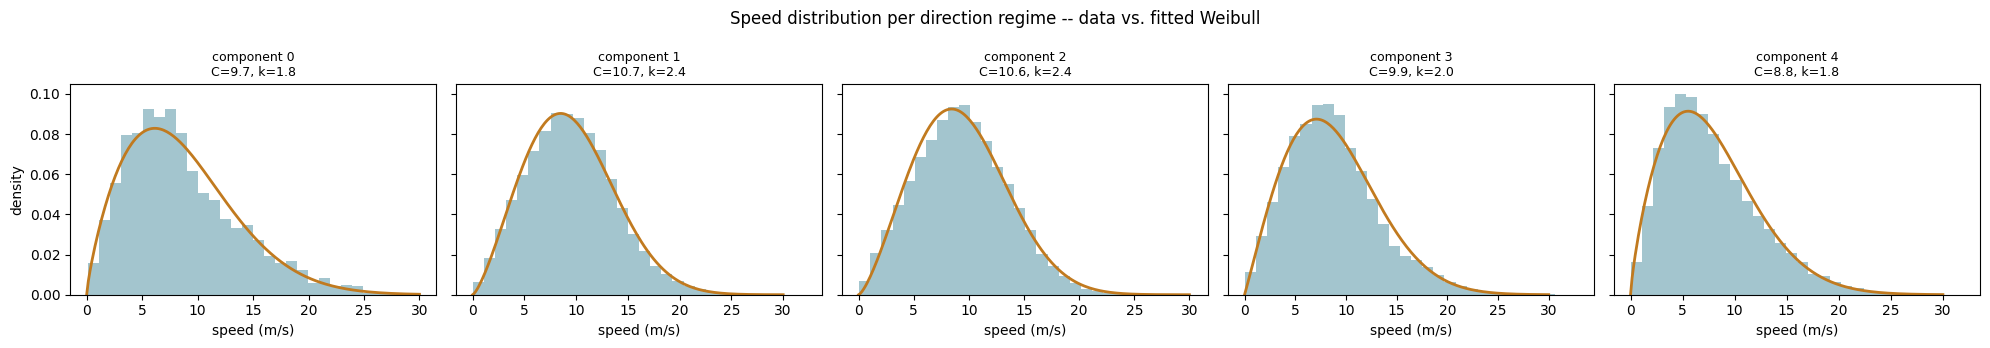

In [28]:
fig, axes = plt.subplots(1, len(estimated_weights), figsize=(4 * len(estimated_weights), 3.5), sharey=True)
ws_grid = np.linspace(0, 30, 200)
for m, ax in enumerate(axes):
    mask = component_id == m
    ax.hist(speeds[mask], bins=30, density=True, alpha=0.4, color="#1B6E86")
    ax.plot(ws_grid, weibull_min.pdf(ws_grid, component_k[m], scale=component_C[m]), color="#C17A1F", linewidth=2)
    ax.set_title(f"component {m}\nC={component_C[m]:.1f}, k={component_k[m]:.1f}", fontsize=9)
    ax.set_xlabel("speed (m/s)")
axes[0].set_ylabel("density")
fig.suptitle("Speed distribution per direction regime -- data vs. fitted Weibull")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "vonmises_component_weibull.png", dpi=180, bbox_inches="tight")
plt.show()

## four stochastic knobs


In [29]:
SECTOR_RAD = np.radians(SECTOR_DEG)

def sample_vonmises_scenario(rng, delta_mu_std_deg=15.0, delta_mu_max_deg=45.0,
                              kappa_spread=0.3, weight_concentration=40.0,
                              sv_mean=1.0, sv_std=0.08):
    delta_mu = np.clip(rng.normal(0, np.radians(delta_mu_std_deg)),
                        -np.radians(delta_mu_max_deg), np.radians(delta_mu_max_deg))
    mus = estimated_mus + delta_mu
    kappa_factor = rng.uniform(1 - kappa_spread, 1 + kappa_spread, size=estimated_kappas.size)
    kappas = np.clip(estimated_kappas * kappa_factor, 0.1, 50.0)
    weights = rng.dirichlet(estimated_weights * weight_concentration)
    s_v = np.clip(rng.normal(sv_mean, sv_std), 0.5, 1.8)
    return dict(delta_mu=delta_mu, mus=mus, kappas=kappas, weights=weights, s_v=s_v)

def scenario_to_site_params(scenario):
    mus, kappas, weights, s_v = scenario["mus"], scenario["kappas"], scenario["weights"], scenario["s_v"]
    dens = np.array([w * vonmises_pdf(SECTOR_RAD, mu, k) for w, mu, k in zip(weights, mus, kappas)])
    freq = dens.sum(axis=0)
    freq = freq / freq.sum()
    local_weight = dens / np.clip(dens.sum(axis=0, keepdims=True), 1e-300, None)
    A = (local_weight * component_C[:, None]).sum(axis=0) * s_v
    k = (local_weight * component_k[:, None]).sum(axis=0)
    return freq, A, k

def sample_vonmises_site(rng, ti=TI, **kwargs):
    scenario = sample_vonmises_scenario(rng, **kwargs)
    freq, A, k = scenario_to_site_params(scenario)
    site = UniformWeibullSite(p_wd=list(freq), a=list(A), k=list(k), ti=ti)
    return site, scenario

_, demo_scenario = sample_vonmises_site(rng)
demo_freq, demo_A, demo_k = scenario_to_site_params(demo_scenario)
print(f"delta_mu={np.degrees(demo_scenario['delta_mu']):+.1f} deg, s_v={demo_scenario['s_v']:.2f}")
print(f"freq sum={demo_freq.sum():.3f}, mean A={demo_A.mean():.2f} m/s, mean k={demo_k.mean():.2f}")

delta_mu=+8.8 deg, s_v=1.08
freq sum=1.000, mean A=10.57 m/s, mean k=2.04


## testing a knob on a time

/var/folders/1j/_3qt8y3s02n_m1mtt8pcvnh00000gr/T/ipykernel_62038/2605872485.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


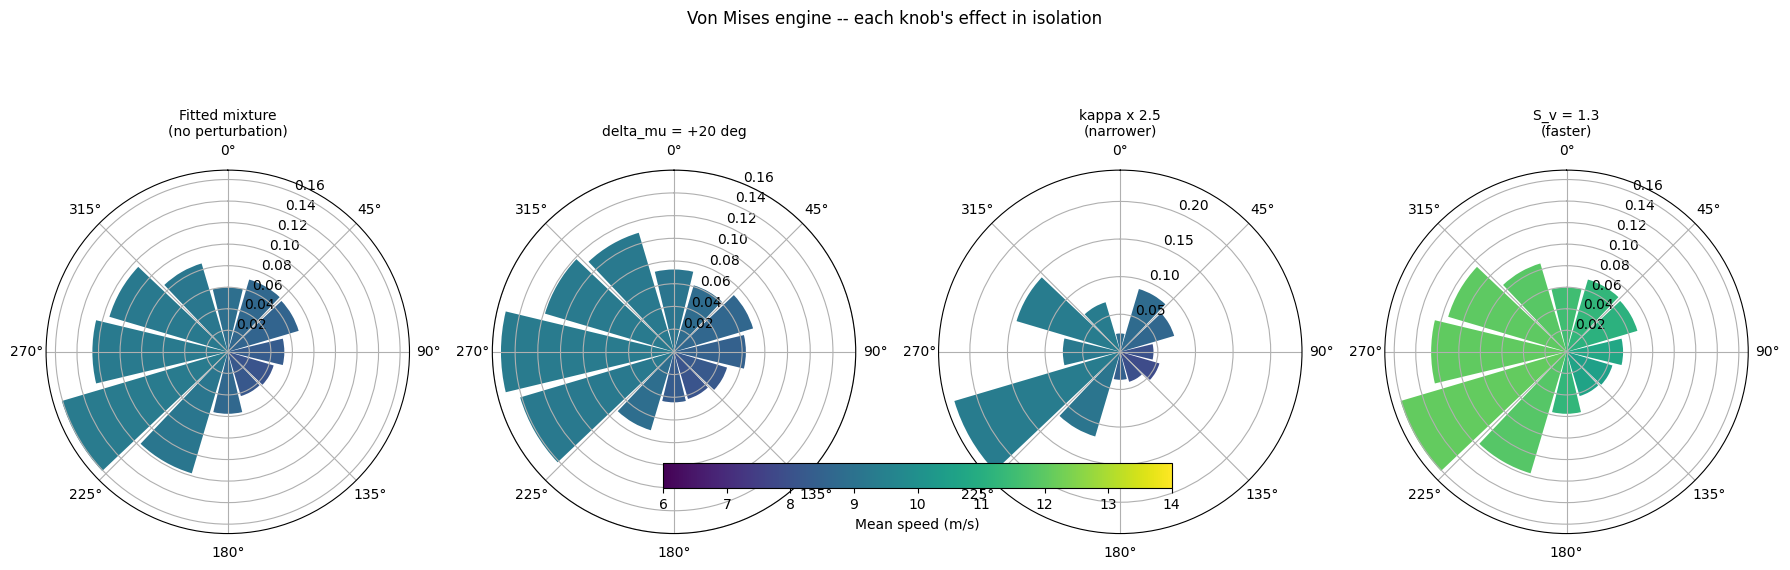

In [ ]:
def rose_from_scenario(scenario):
    freq, A, k = scenario_to_site_params(scenario)
    return np.concatenate([freq, A, k])

neutral = dict(mus=estimated_mus, kappas=estimated_kappas, weights=estimated_weights, s_v=1.0)
rotated = dict(neutral, mus=estimated_mus + np.radians(20))
narrow = dict(neutral, kappas=estimated_kappas * 2.5)
faster = dict(neutral, s_v=1.3)

fig, axes = plt.subplots(1, 4, figsize=(18, 5.5), subplot_kw={"projection": "polar"})
plot_rose(axes[0], rose_from_scenario(neutral), "Fitted mixture\n(no perturbation)")
plot_rose(axes[1], rose_from_scenario(rotated), "delta_mu = +20 deg")
plot_rose(axes[2], rose_from_scenario(narrow), "kappa x 2.5\n(narrower)")
plot_rose(axes[3], rose_from_scenario(faster), "S_v = 1.3\n(faster)")
add_speed_colorbar(fig, axes)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "vonmises_knob_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

## calibrating with past data


In [31]:
def circular_fit(theta):
    n = len(theta)
    sin_sum, cos_sum = np.sin(theta).sum(), np.cos(theta).sum()
    mu = np.arctan2(sin_sum, cos_sum)
    r_bar = np.sqrt(sin_sum ** 2 + cos_sum ** 2) / n
    if r_bar < 0.53:
        kappa = 2 * r_bar + r_bar ** 3 + (5 * r_bar ** 5) / 6
    elif r_bar < 0.85:
        kappa = -0.4 + 1.39 * r_bar + 0.43 / (1 - r_bar)
    else:
        kappa = 1 / (r_bar ** 3 - 4 * r_bar ** 2 + 3 * r_bar)
    return mu, np.clip(kappa, 0.1, 50.0)

year_mus, year_kappas = [], []
for _wind_data in wind_data:
    mu, kappa = circular_fit(np.radians(_wind_data['w_d']))
    year_mus.append(mu)
    year_kappas.append(kappa)
year_mus = np.array(year_mus)
year_kappas = np.array(year_kappas)

pooled_mu = np.arctan2(np.sin(year_mus).mean(), np.cos(year_mus).mean())
year_deviation_deg = np.degrees(np.angle(np.exp(1j * (year_mus - pooled_mu))))

print(f"Pooled dominant direction (mean of 24 yearly means): {np.degrees(pooled_mu) % 360:.0f} deg")
print(f"Year-to-year rotation: std={year_deviation_deg.std():.1f} deg, max={np.abs(year_deviation_deg).max():.1f} deg")
print(f"Year-to-year kappa (K=1, whole rose): mean={year_kappas.mean():.2f}, "
      f"range={year_kappas.min():.2f}-{year_kappas.max():.2f} (logged, not swept this round)")

Pooled dominant direction (mean of 24 yearly means): 267 deg
Year-to-year rotation: std=6.9 deg, max=13.6 deg
Year-to-year kappa (K=1, whole rose): mean=0.54, range=0.43-0.68 (logged, not swept this round)


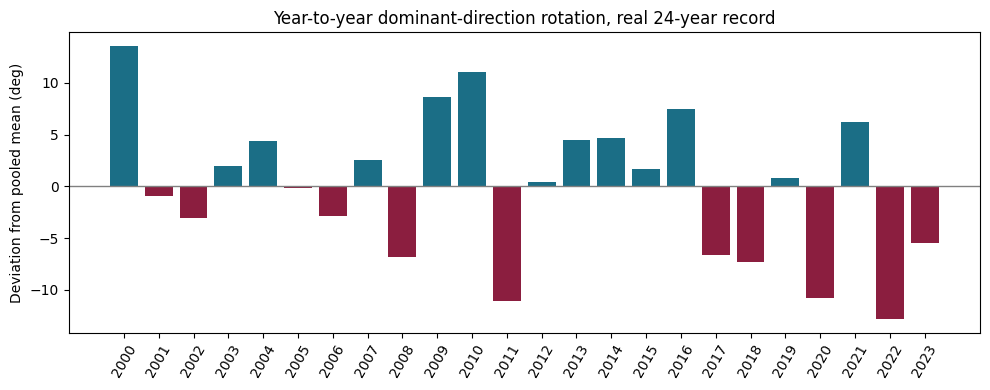

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#1B6E86" if d >= 0 else "#8B1E3F" for d in year_deviation_deg]
ax.bar(YEARS, year_deviation_deg, color=colors)
ax.axhline(0, color="gray", linewidth=1)
ax.set_ylabel("Deviation from pooled mean (deg)")
ax.set_title("Year-to-year dominant-direction rotation, real 24-year record")
ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "delta_mu_year_to_year.png", dpi=180, bbox_inches="tight")
plt.show()

In [ ]:
DELTA_MU_GRID_DEG = np.round(np.linspace(-np.abs(year_deviation_deg).max(), np.abs(year_deviation_deg).max(), 7))
print("Delta_mu sweep grid (deg):", DELTA_MU_GRID_DEG.tolist())

delta_mu_sweep_sites = {}
for d in DELTA_MU_GRID_DEG:
    scenario = dict(mus=estimated_mus + np.radians(d), kappas=estimated_kappas, weights=estimated_weights, s_v=1.0)
    freq, A, k = scenario_to_site_params(scenario)
    delta_mu_sweep_sites[float(d)] = UniformWeibullSite(p_wd=list(freq), a=list(A), k=list(k), ti=TI)


Delta_mu sweep grid (deg): [-14.0, -9.0, -5.0, 0.0, 5.0, 9.0, 14.0]
7 calibrated sites ready -- one UniformWeibullSite per Delta_mu grid point, to be crossed with spacing x turbine downstream


/var/folders/1j/_3qt8y3s02n_m1mtt8pcvnh00000gr/T/ipykernel_62038/1773550842.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


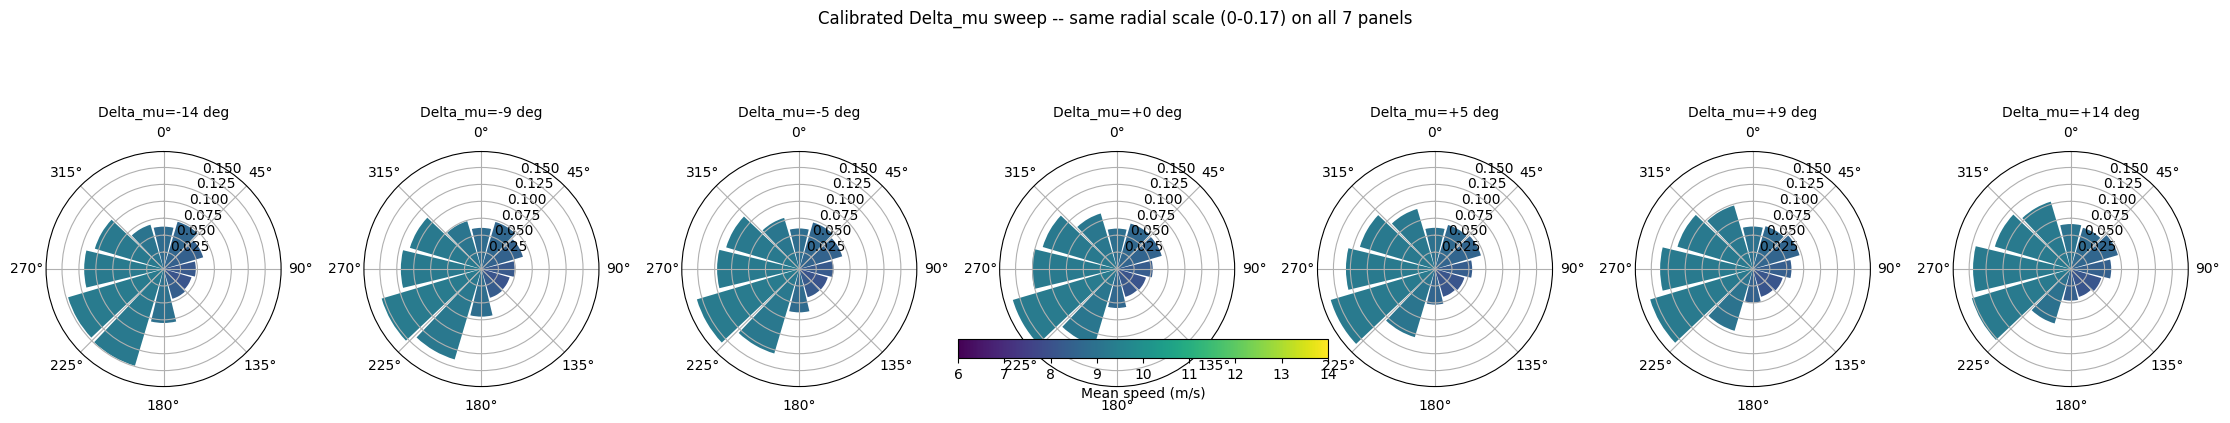

In [ ]:
# shared radial ceiling across all 7 panels, per-panel autoscale hides that the
# tallest bar is actually SMALLER at the extremes, not bigger (see analysis)
sweep_scenarios = [dict(mus=estimated_mus + np.radians(d), kappas=estimated_kappas,
                         weights=estimated_weights, s_v=1.0) for d in DELTA_MU_GRID_DEG]
R_MAX = max(scenario_to_site_params(s)[0].max() for s in sweep_scenarios) * 1.08

fig, axes = plt.subplots(1, len(DELTA_MU_GRID_DEG), figsize=(3.2 * len(DELTA_MU_GRID_DEG), 4), subplot_kw={"projection": "polar"})
for ax, d, scenario in zip(axes, DELTA_MU_GRID_DEG, sweep_scenarios):
    plot_rose(ax, rose_from_scenario(scenario), f"Delta_mu={d:+.0f} deg")
    ax.set_ylim(0, R_MAX)
add_speed_colorbar(fig, axes)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "delta_mu_sweep_grid.png", dpi=180, bbox_inches="tight")
plt.show()